# 03. V3: нагрев ТВЭЛа без отдельного нагрева пара

Версия расчета: `tvel-heating-v3`. Этот notebook проверяет требование: вся энергия вводится только в топливо GeN-Foam, а вода/пар у наружной W-оболочки нагревается только за счет потока от стенки. Отдельного нагревателя пара, прямого энерговвода в пар и обратной искусственной нагрузки на оболочку здесь нет.

Основной вопрос V3: помогает ли увеличение длительности импульса получить область диссоциации воды, не выводя топливо HfC и W-оболочку за температурные пределы.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "build" / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / "build" / "cache"))

import matplotlib.pyplot as plt
import numpy as np

from thesis_modeling.pipeline_v3_export import (
    PIPELINE_V3_VERSION,
    export_pipeline_v3_artifacts,
    pipeline_v3_specs,
    plot_pipeline_v3_tvel_heating,
    run_pipeline_v3,
)


## Сценарии V3

Сценарии различаются только мощностью и длительностью импульса в топливе. Геометрия ТВЭЛа остается той же: радиус топлива 4 мм, зазор 80 мкм, W-оболочка толщиной 0.6 мм и локальный слой воды толщиной 200 мкм. Это намеренно жесткая проверка исходной идеи: сначала меняется только временной профиль энерговвода, а не добавляется внешний нагреватель пара.

In [2]:
spec_rows = [
    {
        "case": spec.label,
        "fuel": spec.fuel_name,
        "clad": spec.clad_name,
        "pulse_duration_s": spec.pulse_duration_s,
        "power_scale_p0": spec.power_scale,
        "water_layer_um": spec.layer_thickness_m * 1e6,
        "genfoam_case_path": spec.genfoam_case_path,
        "role": spec.role,
    }
    for spec in pipeline_v3_specs()
]

spec_rows


[{'case': '\\(HfC\\)--W, \\(4P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'fuel': 'HfC surrogate',
  'clad': 'Tungsten',
  'pulse_duration_s': 1.0,
  'power_scale_p0': 4.0,
  'water_layer_um': 200.0,
  'genfoam_case_path': '/Users/g.elesin/Desktop/Диплом магистратура/data/genfoam/tvel-heating-v3/hfc_w_s4_d1',
  'role': 'мягкий длинный импульс: контроль безопасного, но холодного режима'},
 {'case': '\\(HfC\\)--W, \\(12P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'fuel': 'HfC surrogate',
  'clad': 'Tungsten',
  'pulse_duration_s': 1.0,
  'power_scale_p0': 12.0,
  'water_layer_um': 200.0,
  'genfoam_case_path': '/Users/g.elesin/Desktop/Диплом магистратура/data/genfoam/tvel-heating-v3/hfc_w_s12_d1',
  'role': 'проверка гипотезы о более длинном импульсе при той же суммарной энергии, что у \\(60P_0\\cdot0.2\\,\\mathrm{s}\\)'},
 {'case': '\\(HfC\\)--W, \\(60P_0\\), \\(0.2\\,\\mathrm{s}\\)',
  'fuel': 'HfC surrogate',
  'clad': 'Tungsten',
  'pulse_duration_s': 0.2,
  'power_scale_p0': 60.0,
  'water_layer_um':

## Расчетная схема

GeN-Foam рассчитывает энерговыделение в `nuclearFuelPin`, теплопроводность топлива, зазор, W-оболочку и внешний тепловой отклик. Python не пересчитывает ТВЭЛ. Он берет температуру наружной оболочки и считает только локальный водный контрольный объем:

\[
\frac{dE_w}{dt}=h_{\mathrm{eff}}(\phi,T_W,T_w) A_W\max(T_W-T_w,0),\qquad
A_W=2\pi R_W.
\]

Ограничение контакта со стенкой записывается явно:

\[
E_w(t)\le E_w(T_W(t)),\qquad T_w(t)\le T_W(t).
\]

Далее фазовый баланс переводит энергию в температуру воды/пара: нагрев жидкости, испарение через `L_v`, затем перегрев пара. Cantera получает \(T_w(t)\), давление и начальный состав \(H_2O\), после чего возвращает равновесную долю и массу \(H_2\).

In [3]:
runs = run_pipeline_v3()

summary_rows = []
for run in runs:
    diag = run.diagnostics
    summary_rows.append(
        {
            "case": run.report["case"],
            "version": PIPELINE_V3_VERSION,
            "source": run.result["thermal_source"],
            "adapter": run.result["thermal_adapter"],
            "chemistry": run.chemistry["method"],
            "max_fuel_k": round(diag["max_fuel_k"], 1),
            "max_w_clad_k": round(diag["max_clad_k"], 1),
            "max_steam_k": round(diag["max_steam_k"], 1),
            "steam_energy_percent": round(diag["steam_energy_percent_of_pulse"], 4),
            "h2_eq_mg_per_m": round(diag["peak_h2_mg_per_m"], 6),
            "target_reached": diag["target_reached"],
            "reactor_thermal_ok": diag["reactor_thermal_ok"],
        }
    )

summary_rows


[{'case': '\\(HfC\\)--W, \\(4P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'version': 'tvel-heating-v3',
  'source': 'genfoam',
  'adapter': 'wall_coupled_annular_water',
  'chemistry': 'cantera_equilibrium_tp',
  'max_fuel_k': 2208.4,
  'max_w_clad_k': 1104.5,
  'max_steam_k': 1099.8,
  'steam_energy_percent': 0.0955,
  'h2_eq_mg_per_m': 0.000125,
  'target_reached': False,
  'reactor_thermal_ok': True},
 {'case': '\\(HfC\\)--W, \\(12P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'version': 'tvel-heating-v3',
  'source': 'genfoam',
  'adapter': 'wall_coupled_annular_water',
  'chemistry': 'cantera_equilibrium_tp',
  'max_fuel_k': 5374.4,
  'max_w_clad_k': 2047.7,
  'max_steam_k': 2035.8,
  'steam_energy_percent': 0.0648,
  'h2_eq_mg_per_m': 0.57433,
  'target_reached': False,
  'reactor_thermal_ok': False},
 {'case': '\\(HfC\\)--W, \\(60P_0\\), \\(0.2\\,\\mathrm{s}\\)',
  'version': 'tvel-heating-v3',
  'source': 'genfoam',
  'adapter': 'wall_coupled_annular_water',
  'chemistry': 'cantera_equilibrium_tp'

## Энергетика на метр ТВЭЛа

Эта ячейка раскрывает, почему увеличение длительности помогает, но не решает задачу автоматически. Длинный импульс дает теплу больше времени пройти к W-оболочке и воде, однако температура пара все равно ограничена температурой наружной стенки. Поэтому сравниваются две величины: доля энергии, накопленная в воде/паре, и запас до материальных пределов топлива и оболочки.

In [4]:
energy_rows = []
for run in runs:
    result = run.result
    scenario = run.scenario
    time_s = np.asarray(result["time_s"])
    steam_energy = np.asarray(result["water_energy_j_per_m"])
    pulse_energy = np.asarray(result["pulse_energy_j_per_m"])
    wall_flux = np.asarray(result["wall_heat_flux_w_m2"])
    cap_active = np.asarray(result["wall_temperature_cap_active"])
    peak_i = int(np.argmax(result["water_temperature_k"]))

    energy_rows.append(
        {
            "case": run.report["case"],
            "water_mass_g_per_m": round(scenario.water.mass_kg_per_m * 1e3, 4),
            "time_of_max_steam_s": round(float(time_s[peak_i]), 4),
            "steam_energy_kj_per_m": round(float(np.max(steam_energy)) / 1e3, 4),
            "steam_energy_percent_of_pulse": round(float(np.max(steam_energy) / pulse_energy[-1]) * 100.0, 5),
            "max_wall_heat_flux_mw_m2": round(float(np.max(wall_flux)) / 1e6, 4),
            "wall_temperature_cap_was_active": bool(np.any(cap_active)),
            "fuel_margin_k": round(run.diagnostics["fuel_margin_k"], 1),
            "clad_margin_k": round(run.diagnostics["clad_margin_k"], 1),
        }
    )

energy_rows


[{'case': '\\(HfC\\)--W, \\(4P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'water_mass_g_per_m': 3.9044,
  'time_of_max_steam_s': 1.19,
  'steam_energy_kj_per_m': 9.1659,
  'steam_energy_percent_of_pulse': 0.09548,
  'max_wall_heat_flux_mw_m2': 2.7316,
  'wall_temperature_cap_was_active': True,
  'fuel_margin_k': 1991.6,
  'clad_margin_k': 2590.5},
 {'case': '\\(HfC\\)--W, \\(12P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'water_mass_g_per_m': 3.9044,
  'time_of_max_steam_s': 1.18,
  'steam_energy_kj_per_m': 18.6672,
  'steam_energy_percent_of_pulse': 0.06482,
  'max_wall_heat_flux_mw_m2': 3.7127,
  'wall_temperature_cap_was_active': True,
  'fuel_margin_k': -1174.4,
  'clad_margin_k': 1647.3},
 {'case': '\\(HfC\\)--W, \\(60P_0\\), \\(0.2\\,\\mathrm{s}\\)',
  'water_mass_g_per_m': 3.9044,
  'time_of_max_steam_s': 0.49,
  'steam_energy_kj_per_m': 20.7805,
  'steam_energy_percent_of_pulse': 0.07215,
  'max_wall_heat_flux_mw_m2': 8.0028,
  'wall_temperature_cap_was_active': False,
  'fuel_margin_k': -1989.5

## Проверка физической адекватности V3

Проверка не требует положительного результата по диссоциации. Она требует, чтобы расчет действительно был TVEL-only: реальный ряд GeN-Foam прочитан, стеночно-связанный адаптер включен, полей прямого нагрева пара нет, Cantera считает равновесие, время и энергии физически корректны. После этого отдельно классифицируется физический вывод: безопасно, но холодно; или горячее, но с перегревом топлива.

In [5]:
adequacy_rows = []
for run in runs:
    result = run.result
    chemistry = run.chemistry
    h2 = np.asarray(chemistry["hydrogen_kg_per_m"])
    h2_max = np.asarray(chemistry["max_hydrogen_kg_per_m"])
    row = {
        "case": run.report["case"],
        "genfoam_real_series": result["thermal_source"] == "genfoam",
        "wall_coupled_adapter": result["thermal_adapter"] == "wall_coupled_annular_water",
        "no_direct_steam_heater": "direct_steam_energy_j_per_m" not in result,
        "cantera_equilibrium": bool(chemistry["uses_cantera"]),
        "time_monotonic": bool(np.all(np.diff(result["time_s"]) > 0.0)),
        "nonnegative_water_energy": bool(np.all(np.asarray(result["water_energy_j_per_m"]) >= 0.0)),
        "h2_not_above_stoich": bool(np.all(h2 <= h2_max + 1e-15)),
        "validation_ok": bool(run.validation["ok"]),
        "target_reached": bool(run.diagnostics["target_reached"]),
        "reactor_thermal_ok": bool(run.diagnostics["reactor_thermal_ok"]),
    }
    row["numerics_ok"] = all(
        row[key]
        for key in (
            "genfoam_real_series",
            "wall_coupled_adapter",
            "no_direct_steam_heater",
            "cantera_equilibrium",
            "time_monotonic",
            "nonnegative_water_energy",
            "h2_not_above_stoich",
            "validation_ok",
        )
    )
    row["physical_result"] = (
        "целевой режим"
        if row["target_reached"] and row["reactor_thermal_ok"]
        else "перегрев топлива до парового окна"
        if row["target_reached"]
        else "безопасно, но холодно"
        if row["reactor_thermal_ok"]
        else "перегрев без парового окна"
    )
    adequacy_rows.append(row)

assert all(row["numerics_ok"] for row in adequacy_rows), adequacy_rows
adequacy_rows


[{'case': '\\(HfC\\)--W, \\(4P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'genfoam_real_series': True,
  'wall_coupled_adapter': True,
  'no_direct_steam_heater': True,
  'cantera_equilibrium': True,
  'time_monotonic': True,
  'nonnegative_water_energy': True,
  'h2_not_above_stoich': True,
  'validation_ok': True,
  'target_reached': False,
  'reactor_thermal_ok': True,
  'numerics_ok': True,
  'physical_result': 'безопасно, но холодно'},
 {'case': '\\(HfC\\)--W, \\(12P_0\\), \\(1.0\\,\\mathrm{s}\\)',
  'genfoam_real_series': True,
  'wall_coupled_adapter': True,
  'no_direct_steam_heater': True,
  'cantera_equilibrium': True,
  'time_monotonic': True,
  'nonnegative_water_energy': True,
  'h2_not_above_stoich': True,
  'validation_ok': True,
  'target_reached': False,
  'reactor_thermal_ok': False,
  'numerics_ok': True,
  'physical_result': 'перегрев без парового окна'},
 {'case': '\\(HfC\\)--W, \\(60P_0\\), \\(0.2\\,\\mathrm{s}\\)',
  'genfoam_real_series': True,
  'wall_coupled_adapter': 

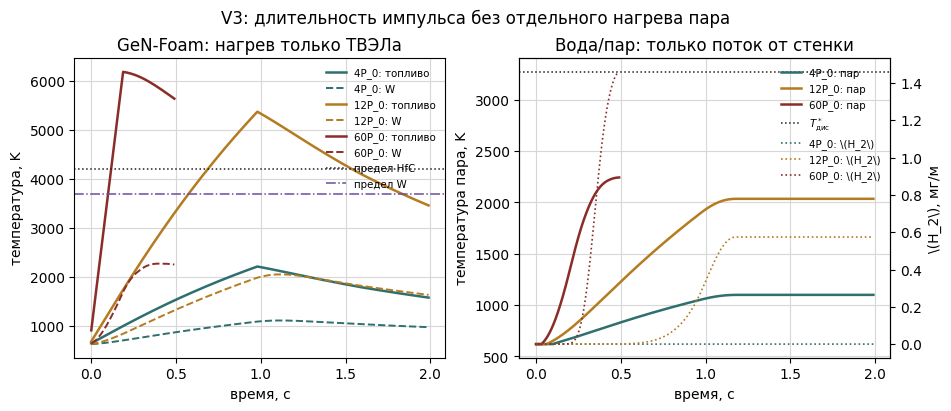

In [6]:
fig = plot_pipeline_v3_tvel_heating(runs)
plt.show()


In [7]:
exported_runs = export_pipeline_v3_artifacts(ROOT / "figures")
[(run.report["case"], round(run.diagnostics["max_steam_k"], 1), round(run.diagnostics["peak_h2_mg_per_m"], 6)) for run in exported_runs]


[('\\(HfC\\)--W, \\(4P_0\\), \\(1.0\\,\\mathrm{s}\\)', 1099.8, 0.000125),
 ('\\(HfC\\)--W, \\(12P_0\\), \\(1.0\\,\\mathrm{s}\\)', 2035.8, 0.57433),
 ('\\(HfC\\)--W, \\(60P_0\\), \\(0.2\\,\\mathrm{s}\\)', 2244.0, 1.459696)]